In [1]:
# This project demonstrates learning Python fundamentals, including data extraction, cleaning, transformation, and merging of multiple datasets.
# The primary dataset was obtained from SEC.gov (EDGAR – Electronic Data Gathering, Analysis, and Retrieval), using Form 13F filings with a filing date of 12 November 2025 and a reporting period ending 30 September 2025.
# I have merged the SEC Form 13F data with:
## CUSIP reference data sourced from GitHub (Repository: yoshishima/Stock_Data, file: cusip.csv)
## Industry classification and company mapping were added using data from: Kaggle – All US Stocks: Tickers, Company Info & Logos (companies.csv dataset)

In [ ]:
# The project focuses on applying core Python fundamentals, including data handling, file I/O, data structures, conditional logic, and data manipulation using libraries such as Pandas and NumPy.
# For data visualization, I learned how to use Matplotlib and Seaborn to present insights clearly and effectively.

In [5]:
# Import Pandas to read and process XML files downloaded from the SEC EDGAR website
# (Form 13F filing: https://www.sec.gov/Archives/edgar/data/2012383/000201238325002949/0002012383-25-002949-index.html)

import pandas as pd

Investor_Reporting_v0 = pd.read_xml('Data//form13fInfoTable.xml')
Investor_Reporting_v1 = pd.read_csv('Data//CUSIP_1.csv')
Investor_Reporting_v2 = pd.read_csv('Data//industry_ classification_1.csv')

In [6]:
# Demonstrates basic Python data types:
# - Object (string)
# - Integer
# - Float (decimal numbers)

Investor_Reporting_v0.dtypes

nameOfIssuer             object
titleOfClass             object
cusip                    object
value                     int64
shrsOrPrnAmt             object
investmentDiscretion     object
otherManager            float64
votingAuthority          object
putCall                  object
dtype: object

In [7]:
Investor_Reporting_v1.dtypes

cusip          object
ticker         object
description    object
dtype: object

In [8]:
Investor_Reporting_v2.dtypes

ticker           object
company name     object
short name       object
industry         object
description      object
website          object
logo             object
ceo              object
exchange         object
market cap      float64
sector           object
tag 1            object
tag 2            object
tag 3            object
dtype: object

In [9]:
Investor_Reporting_merged = pd.merge(Investor_Reporting_v0, Investor_Reporting_v1, on='cusip', how='left')

Investor_Reporting_merged = pd.merge(Investor_Reporting_merged, Investor_Reporting_v2, on='ticker', how='left')

In [10]:
# Below code gives the column names

Investor_Reporting_merged.dtypes

nameOfIssuer             object
titleOfClass             object
cusip                    object
value                     int64
shrsOrPrnAmt             object
investmentDiscretion     object
otherManager            float64
votingAuthority          object
putCall                  object
ticker                   object
description_x            object
company name             object
short name               object
industry                 object
description_y            object
website                  object
logo                     object
ceo                      object
exchange                 object
market cap              float64
sector                   object
tag 1                    object
tag 2                    object
tag 3                    object
dtype: object

In [11]:
Investor_Reporting_merged.columns

Index(['nameOfIssuer', 'titleOfClass', 'cusip', 'value', 'shrsOrPrnAmt',
       'investmentDiscretion', 'otherManager', 'votingAuthority', 'putCall',
       'ticker', 'description_x', 'company name', 'short name', 'industry',
       'description_y', 'website', 'logo', 'ceo', 'exchange', 'market cap',
       'sector', 'tag 1', 'tag 2', 'tag 3'],
      dtype='object')

In [12]:
Investor_Reporting_merged.head(1)

,nameOfIssuer,titleOfClass,cusip,value,shrsOrPrnAmt,investmentDiscretion,otherManager,votingAuthority,putCall,ticker,...,description_y,website,logo,ceo,exchange,market cap,sector,tag 1,tag 2,tag 3
0,1 800 FLOWERS COM INC,CL A,68243Q106,47757,\n\t\t\t,SOLE,2.0,\n\t\t\t,None,FLWS,...,1-800-Flowers.com Inc is a U.S. based provider...,http://www.1800flowers.com,FLWS.png,Christopher G. McCann,Nasdaq Global Select,1.110286e+09,Consumer Cyclical,Consumer Cyclical,Specialty Retail,Retail - Apparel & Specialty


In [14]:
# Below code helps identify rows and column included in the report

Investor_Reporting_merged.shape

(49030, 24)

In [15]:
# Data cleanup naming convention standardization for industry and sector
Investor_Reporting_merged.loc[
    Investor_Reporting_merged['nameOfIssuer'] == 'META PLATFORMS INC', 
    ['industry', 'sector']
] = ['Interactive Media & Services', 'Communication Services']

In [16]:
# Data cleanup naming convention standardization for ticker
Investor_Reporting_merged.loc[
    Investor_Reporting_merged['nameOfIssuer'] == 'ALPHABET INC', 
    ['ticker']
] = ['GOOGL']

In [19]:
# Top Holdings

top_holdings_agg = (
    Investor_Reporting_merged
    .groupby(['nameOfIssuer', 'ticker', 'industry', 'sector'], as_index=False)
    .agg({'value': 'sum'})  # sum value if duplicate
)

top_holdings_agg['value_billion'] = top_holdings_agg['value'] / 1_000_000_000

top_holdings_agg['value_billion'] = top_holdings_agg['value_billion'].round(2)

top_holdings_agg = top_holdings_agg.sort_values('value_billion', ascending=False).head(10)

print(top_holdings_agg[['nameOfIssuer', 'ticker', 'value_billion', 'industry', 'sector']])
pd.set_option('display.width', 1400)

              nameOfIssuer ticker  value_billion                      industry                  sector
1858    NVIDIA CORPORATION   NVDA         360.13                Semiconductors              Technology
1689        MICROSOFT CORP   MSFT         306.62          Application Software              Technology
185              APPLE INC   AAPL         292.30             Computer Hardware              Technology
106           ALPHABET INC  GOOGL         191.48                  Online Media              Technology
113         AMAZON COM INC   AMZN         158.71  Retail - Apparel & Specialty       Consumer Cyclical
423           BROADCOM INC   AVGO         124.80                Semiconductors              Technology
1675    META PLATFORMS INC   META         123.12  Interactive Media & Services  Communication Services
2471             TESLA INC   TSLA          92.00                         Autos       Consumer Cyclical
1423  JPMORGAN CHASE & CO.    JPM          65.99                         

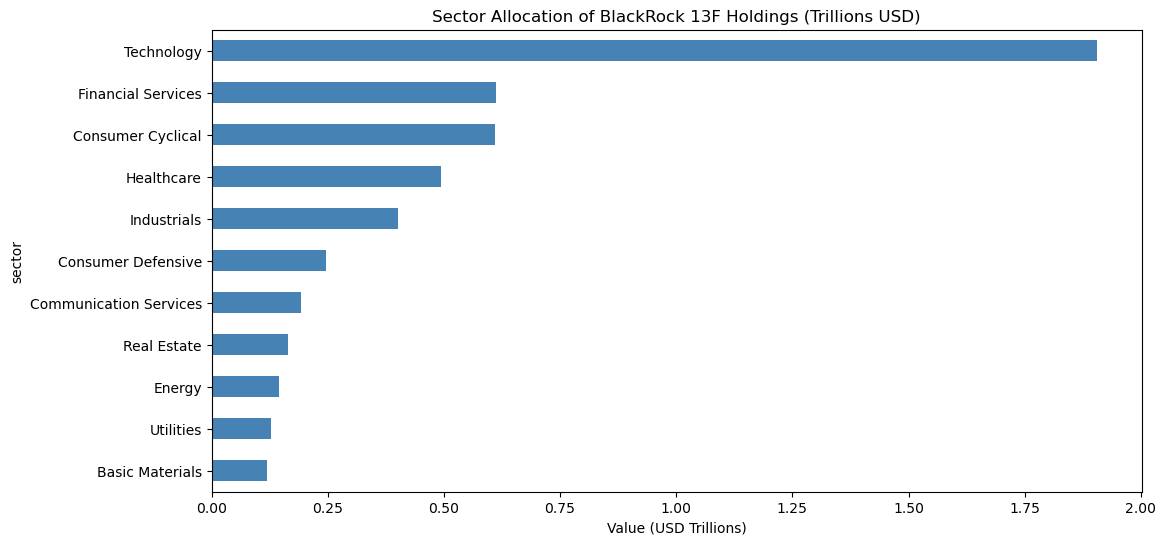

In [28]:
# Sector Allocation

import matplotlib.pyplot as plt #Creates various types of plots within the current figure and axes.
import matplotlib.ticker as ticker #

# Aggregate and convert to trillions
sector_allocation = (
    Investor_Reporting_merged
    .groupby('sector')['value']
    .sum()
    .sort_values(ascending=False) / 1_000_000_000_000
)

# Plot
plt.figure(figsize=(12,6))
sector_allocation.plot(kind='barh', color='steelblue')

plt.xlabel('Value (USD Trillions)')
plt.title('Sector Allocation of BlackRock 13F Holdings (Trillions USD)')
plt.gca().invert_yaxis()

# Format x-axis to 2 decimals
plt.gca().xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

plt.show()

<Axes: title={'center': 'Industry Allocation within Technology'}, xlabel='industry'>

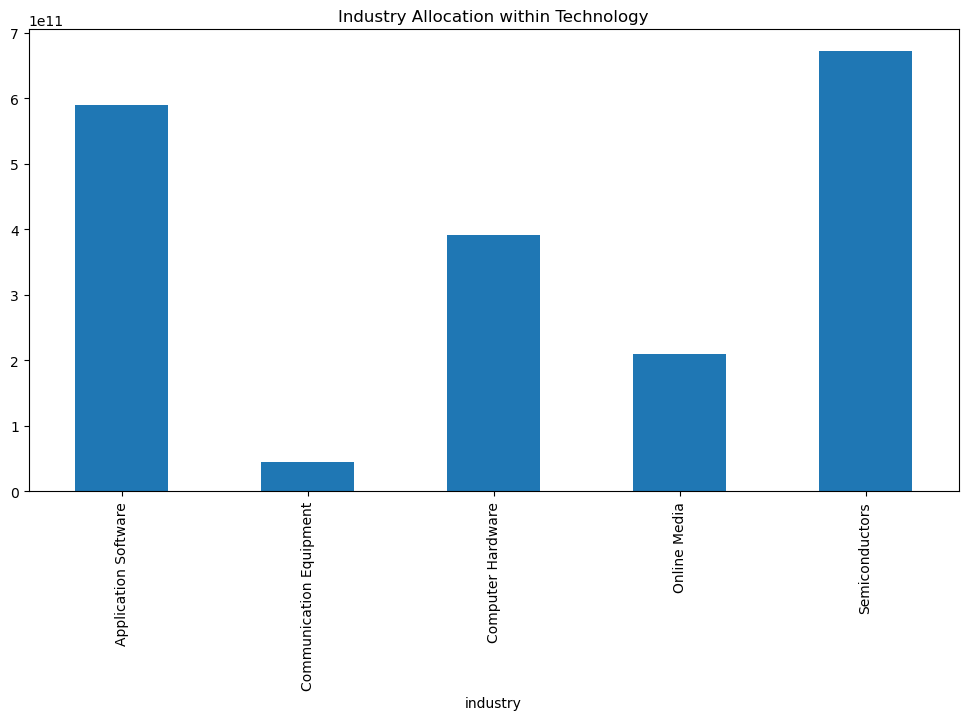

In [22]:
# Industry Allocation within Top Sector

top_sector = sector_allocation.index[0]
industry_allocation = Investor_Reporting_merged[Investor_Reporting_merged['sector']==top_sector].groupby('industry')['value'].sum()
industry_allocation.plot(kind='bar', figsize=(12,6), title=f'Industry Allocation within {top_sector}')

In [24]:
# Investor Confidence / Diversification

top_5_pct = Investor_Reporting_merged.sort_values('value', ascending=False)['value'].head(5).sum() / Investor_Reporting_merged['value'].sum()
print(f"Top 5 holdings account for {top_5_pct:.2%} of total portfolio")

Top 5 holdings account for 9.23% of total portfolio


In [29]:
# save Final file for future reference

Investor_Reporting_merged.to_csv('Data//BlackRock_13F_Master.csv', index=False)